# Molecular dynamics: depinning under applied force and torque

This notebook drives a rigid cluster with an applied external force (Fx)
or torque (Tau) and finds the depinning transition: the critical force Fc
(or critical torque Tau_c) above which the cluster begins to slide.

The dynamics follow the Euler-Maruyama overdamped Langevin equation:

  eta_t * dx_cm/dt = Fx + Fx_substrate + noise_x
  eta_t * dy_cm/dt = Fy + Fy_substrate + noise_y
  eta_r * dtheta/dt = Tau + Tau_substrate + noise_theta

where eta_t and eta_r are the translational and rotational drag coefficients
(computed from N and the moment of inertia), and the noise satisfies FDT:
variance = 2 * kBT / (eta * dt).

`sweep_md` runs one MD trajectory per grid point (here: per Fx or Tau value)
in parallel, then applies a post-processing function to extract a scalar metric
(drift velocity or angular velocity). The depinning appears as a sharp onset
in that metric.

In [1]:
import numpy as np
from numpy import sqrt
import matplotlib.pyplot as plt
from time import time

from flake.substrate import substrate_from_params, get_ks
from flake.cluster import cluster_from_params, calc_cluster_langevin
from flake.dynamics import run_md
from flake.sweep import sweep_md, grid_sweep, drift_velocity, mean_velocity

## System definition

Commensurate cluster on a sinusoidal triangular substrate (rho=1).
Same geometry as the barrier notebook so the depinning force Fc is
directly comparable to the static friction Fs computed from the MEP.

`kBT=1e-8` instead of 0 avoids saddle-point ambiguity in the EM integrator.
At epsilon=1 this is thermally negligible (T is effectively zero).

N=223  E=-223  eta_t=223  eta_r=6.86e+03  eta_r/eta_t=30.8


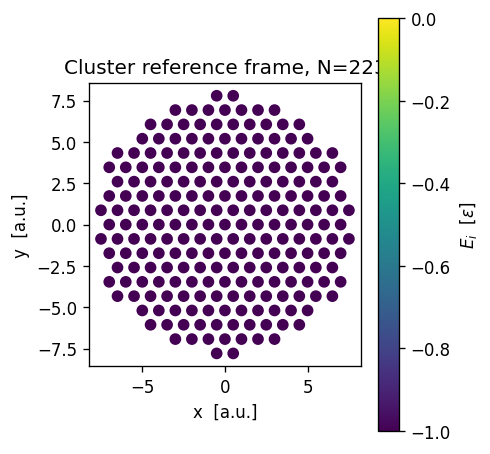

In [2]:
ks = get_ks(1, 3, 4./3., 0.)   # triangular substrate wave vectors

params = {
    'sub_basis':     [[0, 0]],
    'epsilon':       1,
    'well_shape':    'sin',
    'ks':            ks,
    'a1':            np.array([1.,  0.]),
    'a2':            np.array([0.5, -sqrt(3.)/2.]),
    'cl_basis':      [[0, 0]],
    'cluster_shape': 'circle',
    'N1': 15, 'N2': 15,
    'theta': 0.0, 'pos_cm': [0., 0.],
}

pen_func, en_func, en_inputs = substrate_from_params(params)
pos = cluster_from_params(params)
N   = pos.shape[0]

# Translational and rotational drag coefficients.
# eta_r / eta_t ~ <r^2> / 1 sets the ratio of rotational to translational
# relaxation times -- larger clusters relax rotationally more slowly.
eta = 1.0
eta_t, eta_r = calc_cluster_langevin(eta, pos)
pen = pen_func(pos + params['pos_cm'], params['pos_cm'], *en_inputs)[0]
print('N=%i  E=%.3g  eta_t=%.3g  eta_r=%.3g  eta_r/eta_t=%.3g'
      % (N, np.sum(pen), eta_t, eta_r, eta_r/eta_t))

fig, ax = plt.subplots(dpi=120, figsize=(4, 4))
sc = ax.scatter(pos[:, 0], pos[:, 1], c=pen, vmin=-params['epsilon'], vmax=0)
plt.colorbar(sc, ax=ax, label=r'$E_i$  [$\epsilon$]')
ax.set_xlabel('x  [a.u.]')
ax.set_ylabel('y  [a.u.]')
ax.set_title('Cluster reference frame, N=%d' % N)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Single trajectory: below and above depinning

Before running the full sweep it is instructive to watch individual
trajectories at Fx just below and just above the depinning threshold.
This gives a physical intuition for what the sweep is measuring.

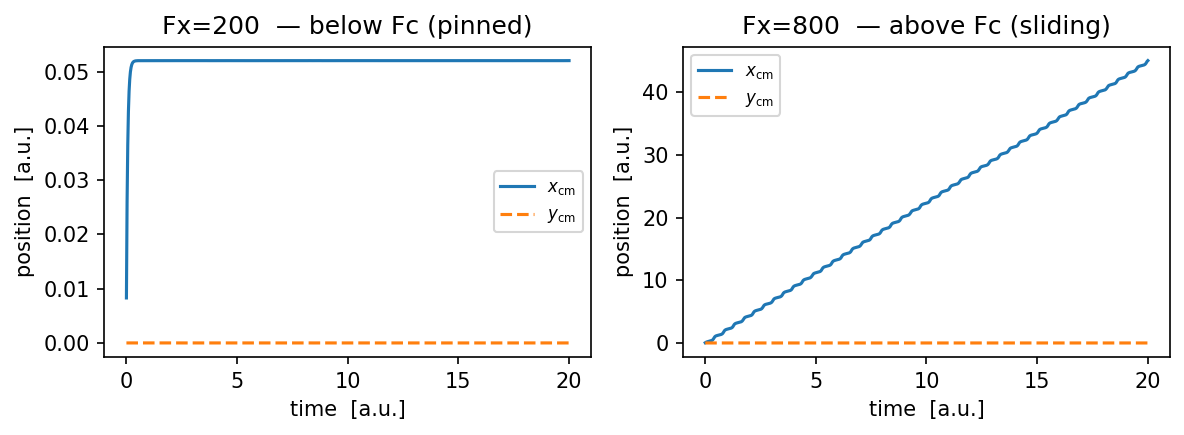

In [6]:
base_kw = dict(
    eta=1.0, kBT=1e-8, dt=1e-3, n_steps=20000,
    Tau=0., print_every=10,
    pos_cm0=params['pos_cm'],
)

fig, axes = plt.subplots(1, 2, dpi=150, figsize=(8, 3))
for ax, Fx_test, label in [
    (axes[0], 200.,  'below Fc (pinned)'),
    (axes[1], 800.,  'above Fc (sliding)'),
]:
    traj = run_md(pos, en_func, en_inputs, Fx=Fx_test, **base_kw)
    t, xcm, ycm = traj['t'], traj['pos_cm'][:, 0], traj['pos_cm'][:, 1]
    ax.plot(t, xcm, label=r'$x_\mathrm{cm}$')
    ax.plot(t, ycm, label=r'$y_\mathrm{cm}$', ls='--')
    ax.set_xlabel('time  [a.u.]')
    ax.set_ylabel('position  [a.u.]')
    ax.set_title('Fx=%.0f  — %s' % (Fx_test, label))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Force sweep: translational depinning

`grid_sweep({'Fx': ...})` generates one parameter set per Fx value.
`drift_velocity()` post-processes each trajectory to extract
(x_f - x_0) / (t_f - t_0) -- a scalar that is ~0 in the pinned state
and grows linearly above depinning.

`n_jobs=-1` uses all available CPUs; each trajectory is independent.
Results are saved to `outdir` so they can be reloaded without re-running.

In [8]:
t0 = time()

spec = grid_sweep({'Fx': np.linspace(0., 1000., 50)})

results = sweep_md(
    pos, en_func, en_inputs, spec,
    base_md_kwargs={
        'eta':         1.0,
        'kBT':         1e-8,
        'dt':          1e-3,
        'n_steps':     10000,
        'Tau':         0.,
        'print_every': 10,
        'pos_cm0':     params['pos_cm'],
    },
    post_fn=drift_velocity(),
    n_jobs=-1,
    outdir='sweep_depinning_Fx',
    save=True,
    overwrite=True,
    verbose=True,
)

Fx_vals = np.array([r['params']['Fx'] for r in results])
vdrift  = np.array([r['result']       for r in results])

print('Done: %.1fmin' % ((time() - t0) / 60.))

[sweep_md] 1 / 50
[sweep_md] 2 / 50
[sweep_md] 3 / 50
[sweep_md] 4 / 50
[sweep_md] 5 / 50
[sweep_md] 6 / 50
[sweep_md] 7 / 50
[sweep_md] 8 / 50
[sweep_md] 9 / 50
[sweep_md] 10 / 50
[sweep_md] 11 / 50
[sweep_md] 12 / 50
[sweep_md] 13 / 50
[sweep_md] 14 / 50
[sweep_md] 15 / 50
[sweep_md] 16 / 50
[sweep_md] 17 / 50
[sweep_md] 18 / 50
[sweep_md] 19 / 50
[sweep_md] 20 / 50
[sweep_md] 21 / 50
[sweep_md] 22 / 50
[sweep_md] 23 / 50
[sweep_md] 24 / 50
[sweep_md] 25 / 50
[sweep_md] 26 / 50
[sweep_md] 27 / 50
[sweep_md] 28 / 50
[sweep_md] 29 / 50
[sweep_md] 30 / 50
[sweep_md] 31 / 50
[sweep_md] 32 / 50
[sweep_md] 33 / 50
[sweep_md] 34 / 50
[sweep_md] 35 / 50
[sweep_md] 36 / 50
[sweep_md] 37 / 50
[sweep_md] 38 / 50
[sweep_md] 39 / 50
[sweep_md] 40 / 50
[sweep_md] 41 / 50
[sweep_md] 42 / 50
[sweep_md] 43 / 50
[sweep_md] 44 / 50
[sweep_md] 45 / 50
[sweep_md] 46 / 50
[sweep_md] 47 / 50
[sweep_md] 48 / 50
[sweep_md] 49 / 50
[sweep_md] 50 / 50


Done: 0.1min


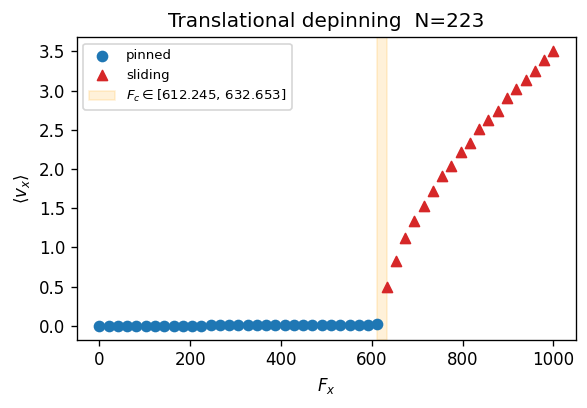

In [10]:
# The depinning transition appears as a sharp onset in drift velocity.
# Below Fc: vdrift ~ 0 (pinned). Above Fc: vdrift grows linearly with F - Fc.
# The orange band brackets the transition region [last pinned, first sliding].
#
# The threshold 1e-2 is appropriate here because kBT=1e-8 so thermal drift
# is negligible -- any vx > 1e-2 is genuine sliding.

fig, ax = plt.subplots(dpi=120, figsize=(5, 3.5))

pinned  = vdrift[:, 0] < 1e-1
sliding = ~pinned

ax.scatter(Fx_vals[pinned],  vdrift[pinned,  0], color='tab:blue',
           label='pinned', zorder=3)
ax.scatter(Fx_vals[sliding], vdrift[sliding, 0], color='tab:red',
           marker='^', label='sliding', zorder=3)

if sliding.any() and pinned.any():
    Fc_lo = Fx_vals[pinned].max()
    Fc_hi = Fx_vals[sliding].min()
    ax.axvspan(Fc_lo, Fc_hi, alpha=0.15, color='orange',
               label=r'$F_c \in [%.3f,\, %.3f]$' % (Fc_lo, Fc_hi))

ax.set_xlabel(r'$F_x$')
ax.set_ylabel(r'$\langle v_x \rangle$')
ax.legend(fontsize=8)
ax.set_title('Translational depinning  N=%i' % N)
plt.tight_layout()
plt.show()

## Torque sweep: rotational depinning

Same idea, but driving the cluster with an applied torque Tau instead of Fx.
`drift_omega` extracts (theta_f - theta_0) / (t_f - t_0), the angular drift velocity.
A sharp onset in omega marks the rotational depinning threshold Tau_c.

In [12]:
def drift_omega():
    """Post-processing: return angular drift velocity dtheta/dt in deg/time."""
    def _post_fn(traj_dict, run_params):
        theta  = traj_dict['theta']
        t      = traj_dict['t']
        dt_tot = float(t[-1] - t[0])
        if dt_tot == 0.:
            return 0.
        return (theta[-1] - theta[0]) / dt_tot
    return _post_fn


t0 = time()

spec_tau = grid_sweep({'Tau': np.linspace(0., 6000., 50)})

results_tau = sweep_md(
    pos, en_func, en_inputs, spec_tau,
    base_md_kwargs={
        'eta':         1.0,
        'kBT':         1e-8,
        'dt':          1e-3,
        'n_steps':     50000,
        'print_every': 10,
    },
    post_fn=drift_omega(),
    n_jobs=-1,
    outdir='sweep_depinning_tau',
    save=True,
    overwrite=True,
)

Tau_vals = np.array([r['params']['Tau'] for r in results_tau])
odrift   = np.array([r['result']        for r in results_tau])

print('Done: %.1fmin' % ((time() - t0) / 60.))

[sweep_md] 1 / 50
[sweep_md] 2 / 50
[sweep_md] 3 / 50
[sweep_md] 4 / 50
[sweep_md] 5 / 50
[sweep_md] 6 / 50
[sweep_md] 7 / 50
[sweep_md] 8 / 50
[sweep_md] 9 / 50
[sweep_md] 10 / 50
[sweep_md] 11 / 50
[sweep_md] 12 / 50
[sweep_md] 13 / 50
[sweep_md] 14 / 50
[sweep_md] 15 / 50
[sweep_md] 16 / 50
[sweep_md] 17 / 50
[sweep_md] 18 / 50
[sweep_md] 19 / 50
[sweep_md] 20 / 50
[sweep_md] 21 / 50
[sweep_md] 22 / 50
[sweep_md] 23 / 50
[sweep_md] 24 / 50
[sweep_md] 25 / 50
[sweep_md] 26 / 50
[sweep_md] 27 / 50
[sweep_md] 28 / 50
[sweep_md] 29 / 50
[sweep_md] 30 / 50
[sweep_md] 31 / 50
[sweep_md] 32 / 50
[sweep_md] 33 / 50
[sweep_md] 34 / 50
[sweep_md] 35 / 50
[sweep_md] 36 / 50
[sweep_md] 37 / 50
[sweep_md] 38 / 50
[sweep_md] 39 / 50
[sweep_md] 40 / 50
[sweep_md] 41 / 50
[sweep_md] 42 / 50
[sweep_md] 43 / 50
[sweep_md] 44 / 50
[sweep_md] 45 / 50
[sweep_md] 46 / 50
[sweep_md] 47 / 50
[sweep_md] 48 / 50
[sweep_md] 49 / 50
[sweep_md] 50 / 50


Done: 0.3min


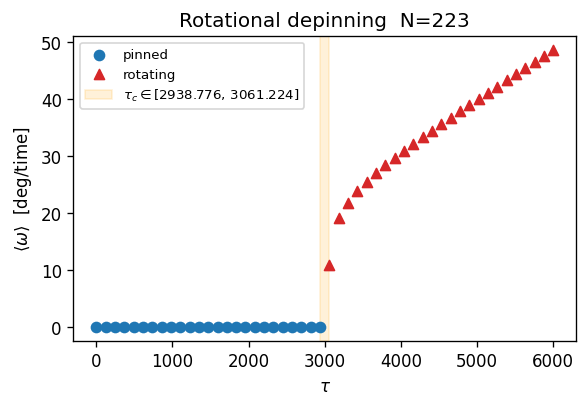

In [14]:
# Threshold 1e-1: higher than translational because rotational trajectories
# run for more steps (n_steps=50000) and the angular drift is noisier.
# Adjust downward if the sweep runs longer.

fig, ax = plt.subplots(dpi=120, figsize=(5, 3.5))

pinned   = odrift < 1e-1
rotating = ~pinned

ax.scatter(Tau_vals[pinned],   odrift[pinned],   color='tab:blue',
           label='pinned', zorder=3)
ax.scatter(Tau_vals[rotating], odrift[rotating], color='tab:red',
           marker='^', label='rotating', zorder=3)

if rotating.any() and pinned.any():
    Tau_lo = Tau_vals[pinned].max()
    Tau_hi = Tau_vals[rotating].min()
    ax.axvspan(Tau_lo, Tau_hi, alpha=0.15, color='orange',
               label=r'$\tau_c \in [%.3f,\, %.3f]$' % (Tau_lo, Tau_hi))

ax.set_xlabel(r'$\tau$')
ax.set_ylabel(r'$\langle \omega \rangle$  [deg/time]')
ax.legend(fontsize=8)
ax.set_title('Rotational depinning  N=%i' % N)
plt.tight_layout()
plt.show()